# Analyse Exploratoire

### Import des modules

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import os
import numpy as np

In [5]:

# Définir le chemin vers le fichier source
input_file = "data/2016_Building_Energy_Benchmarking.csv"
output_file = "data/2016_Building_Energy_Benchmarking_Purge.csv"

# Lire le fichier CSV
df = pd.read_csv(input_file)

# Afficher les noms de colonnes pour repérer celle correspondant à l’usage
print("Colonnes disponibles :", df.columns.tolist())

# Voici les valeurs à garder :
non_residential_keywords = [
    "NonResidential",
    "Nonresidential COS",
    "Nonresidential WA",
    "SPS-District K-12",
    "Campus"
]

# Adapter ici avec le vrai nom de la colonne d’usage
usage_column = "BuildingType"  # remplace si le nom est différent

# Filtrer les lignes contenant les types spécifiés
filtered_df = df[df[usage_column].isin(non_residential_keywords)]

# Sauvegarder le résultat dans un nouveau fichier CSV
filtered_df.to_csv(output_file, index=False)

print(f"Fichier filtré enregistré dans : {output_file}")


Colonnes disponibles : ['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address', 'City', 'State', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus', 'Outlier', 'TotalGHGEmissions', 'GHGEmissionsIntensity']
Fichier filtré enregistré dans :

### Aperçu général

In [6]:
# 1. Chargement des données et aperçu général 
building_consumption = pd.read_csv("data/2016_Building_Energy_Benchmarking_Purge.csv")
# Aperçu général
print("Dimensions :", building_consumption.shape)
print("\nColonnes :", building_consumption.columns.tolist())
building_consumption.head(5)


Dimensions : (1668, 46)

Colonnes : ['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address', 'City', 'State', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus', 'Outlier', 'TotalGHGEmissions', 'GHGEmissionsIntensity']


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


### Infos sur les types de données -  valeurs nulles & non nulles

In [7]:
# 2. Informations générales sur les colonnes
# Infos sur les types de données et valeurs non nulles
building_consumption.info()

# Statistiques descriptives des colonnes numériques
# building_consumption.describe(include='number').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1668 entries, 0 to 1667
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1668 non-null   int64  
 1   DataYear                         1668 non-null   int64  
 2   BuildingType                     1668 non-null   object 
 3   PrimaryPropertyType              1668 non-null   object 
 4   PropertyName                     1668 non-null   object 
 5   Address                          1668 non-null   object 
 6   City                             1668 non-null   object 
 7   State                            1668 non-null   object 
 8   ZipCode                          1652 non-null   float64
 9   TaxParcelIdentificationNumber    1668 non-null   object 
 10  CouncilDistrictCode              1668 non-null   int64  
 11  Neighborhood                     1668 non-null   object 
 12  Latitude            

### y-a-t-il des valeurs manquantes ?

In [8]:
#  3. Analyse des valeurs manquantes building_consumption
# Nombre et pourcentage de valeurs manquantes par colonne
missing_data = building_consumption.isnull().sum().to_frame('MissingCount')
missing_data['MissingPct'] = 100 * missing_data['MissingCount'] / len(building_consumption)
missing_data = missing_data[missing_data['MissingCount'] > 0].sort_values(by='MissingPct', ascending=False)

missing_data


,MissingCount,MissingPct
Comments,1668,100.000000
Outlier,1651,98.980815
YearsENERGYSTARCertified,1570,94.124700
ThirdLargestPropertyUseType,1315,78.836930
ThirdLargestPropertyUseTypeGFA,1315,78.836930
SecondLargestPropertyUseType,813,48.741007
SecondLargestPropertyUseTypeGFA,813,48.741007
ENERGYSTARScore,574,34.412470
ZipCode,16,0.959233
LargestPropertyUseTypeGFA,6,0.359712


In [17]:
# 4. Analyse des variables catégorielles

# Colonnes de type "object" (catégorielles ou texte)
cat_cols = building_consumption.select_dtypes(include='object').columns.tolist()

# Nombre de modalités uniques par variable catégorielle
building_consumption[cat_cols].nunique().sort_values(ascending=False)


PropertyName                     1664
Address                          1647
TaxParcelIdentificationNumber    1587
ListOfAllPropertyUseTypes         373
YearsENERGYSTARCertified           64
LargestPropertyUseType             56
SecondLargestPropertyUseType       47
ThirdLargestPropertyUseType        39
PrimaryPropertyType                22
Neighborhood                       19
BuildingType                        5
ComplianceStatus                    4
Outlier                             2
State                               1
City                                1
dtype: int64


# 🏢 Analyse Sémantique des Colonnes avec Types

✅ **Structure thématique** (par sections)  
✅ **Descriptions précises et synthétiques**  
✅ **Typologie de données intégrées** de façon concise  
✅ **Première analyse** en termes de **variable de prédiction (VP)** et **variable cible (VC)**  

---

## 🧾 Informations Générales sur les Bâtiments

| Colonne                         | Description                                                      | Type    | Comments          |
| ------------------------------- | ---------------------------------------------------------------- | ------- | ------------------|
| `OSEBuildingID`                 | Identifiant unique attribué par la ville à chaque bâtiment.      | `int`   | ------------------|       
| `DataYear`                      | Année de collecte ou de déclaration des données (ici : 2016).    | `int`   | ----fixe (2016) --|
| `BuildingType`                  | Catégorie générale du bâtiment (ex : NonResidential, Campus...). | `cat`   | -pas très précis X|
| `PrimaryPropertyType`           | Type principal d’usage du bâtiment (ex : Hotel, Office...).      | `cat`   | VP potentielle ---|
| `PropertyName`                  | Nom ou désignation commerciale du bâtiment.                      | `text`  | ----inutile ----X-|
| `Address`                       | Adresse postale complète du bâtiment.                            | `text`  | ---localisation-X-|
| `City`                          | Ville où est situé le bâtiment.                                  | `cat`   | ---localisation-X-|
| `State`                         | Code de l’État (ex : WA pour Washington).                        | `cat`   | ---localisation-X-|
| `ZipCode`                       | Code postal (peut être manquant ou arrondi).                     | `float` | ---localisation-X-|
| `TaxParcelIdentificationNumber` | Identifiant fiscal unique de la parcelle cadastrale.             | `text`  | ---Admin  X ------|

---

## 🗺️ Localisation Administrative 

| Colonne                   | Description                                        | Type   | Comments            |
|---------------------------|----------------------------------------------------|--------|---------------------|
| `CouncilDistrictCode`     | Code du district municipal (conseil de quartier).  | `int`  | ---localisation-X---|
| `Neighborhood`            | Nom du quartier de Seattle.                        | `cat`  | ---localisation-X---|
| `Latitude` / `Longitude`  | Coordonnées géographiques du bâtiment.             | `float`| ---localisation-X---|



---

## 🏗️ Caractéristiques Physiques du Bâtiment

| Colonne                  | Description                                    | Type    | Commments          |
| ------------------------ | ---------------------------------------------- | ------- | ------------------ |
| `YearBuilt`              | Année de construction du bâtiment principal.   | `int`   | VP potentielle ----| 
| `NumberofBuildings`      | Nombre de bâtiments sur le site.               | `float?`| VP potentielle ----| 
| `NumberofFloors`         | Nombre d’étages du bâtiment principal.         | `int`   | VP potentielle ----| 
| `PropertyGFATotal`       | Surface brute totale (GFA = Gross Floor Area). | `int`   | utile temp---------| 
| `PropertyGFAParking`     | Surface utilisée pour le stationnement.        | `int`   | utile temp---------|  
| `PropertyGFABuilding(s)` | Surface brute construite hors parking.         | `int`   | utile temp---------| 

---

## 🧰 Usage et Fonction du Bâtiment plus précisément

| Colonne                           | Description                                          | Type    | Comments          |
|-----------------------------------|------------------------------------------------------|---------|-------------------|
| `ListOfAllPropertyUseTypes`       | Tous les usages déclarés (texte libre ou concaténé). | `text`  | pas très précis X |
| `PrimaryPropertyType`             | type de bâtiment (hôtel, bureau, école…).            | `cat`   | VP potentielle ---| 
| `LargestPropertyUseType`          | Usage majoritaire du bâtiment.                       | `cat`   | --- redondant ----| 
| `LargestPropertyUseTypeGFA`       | Surface dédiée à cet usage principal.                | `float` | trop précis X     |
| `SecondLargestPropertyUseType`    | Deuxième usage principal (si applicable).            | `cat`   | trop précis X     |
| `SecondLargestPropertyUseTypeGFA` | Surface correspondante.                              | `float` | trop précis X     |
| `ThirdLargestPropertyUseType`     | Troisième usage principal.                           | `cat`   | trop précis X     |
| `ThirdLargestPropertyUseTypeGFA`  | Surface correspondante.                              | `float` | trop précis X     |

---

## 🌟 Certifications & Scores Énergétiques


| Colonne                    | Description                                       | Type    | Comments          |
|----------------------------|-------------------------------------------------- |---------|-------------------|
| `YearsENERGYSTARCertified` | Années où le bâtiment a été certifié ENERGY STAR. | `text`  | peu renseignée ---|
| `ENERGYSTARScore`          | Score d’efficacité énergétique de 1 à 100.        | `float` | peu renseignée ---|

---

## 🔋 Indicateurs d’Efficacité Énergétique


| Colonne                | Description                                         | Type    | Comments          |
|------------------------|-----------------------------------------------------|---------|-------------------|
| `SiteEUI(kBtu/sf)`     | EUI (Energy Use Intensity) sur site, en kBtu/pied². | `float` | ----inutile ----X-|
| `SiteEUIWN(kBtu/sf)`   | EUI sur site, corrigé météo.                        | `float` | ----inutile ----X-|
| `SourceEUI(kBtu/sf)`   | EUI à la source (inclut pertes réseau).             | `float` | ----inutile ----X-|
| `SourceEUIWN(kBtu/sf)` | EUI source, corrigé météo.                          | `float` | ----inutile ----X-|

---

## ⚡ Consommation d’Énergie

| Colonne                 | Description                            | Type    | Comms               |
| ----------------------- | -------------------------------------- | ------- | ------------------- |
| `SiteEnergyUse(kBtu)`   | Consommation  totale du site           | `float` | ---V Cible ---------|
| `SiteEnergyUseWN(kBtu)` | Idem, corrigée des effets climatiques. | `float` | --liée à la V Cible-|
| `SteamUse(kBtu)`        | Consommation de vapeur en kBtu.        | `float` | --No use -----------|
| `Electricity(kWh)`      | Consommation d’électricité en kWh.     | `float` | --No use -----------|
| `Electricity(kBtu)`     | Électricité convertie en kBtu.         | `float` | --No use -----------|
| `NaturalGas(therms)`    | Consommation de gaz en therms.         | `float` | --No use -----------|
| `NaturalGas(kBtu)`      | Gaz converti en kBtu.                  | `float` | --No use -----------|

---

## 📋 Métadonnées et Statuts 

| Colonne            | Description                                                    | Type      | Comments          |
|--------------------|----------------------------------------------------------------|-----------|-------------------|
| `DefaultData`      | Indique si des valeurs par défaut ont été utilisées (booléen). | `bool`    | ----No use -------|
| `Comments`         | Champ libre (aucune donnée renseignée ici).                    | `NaN`     | ----No use -------|
| `ComplianceStatus` | Statut de conformité du bâtiment (Compliant, etc.).            | `cat`     | ----No use -------|
| `Outlier`          | Indicateur de données aberrantes ou exclues ??                 |`float/NaN`| ----No use -------|

---

## 🌍 Émissions de Gaz à Effet de Serre (GES)

| Colonne                | Description                                                | Type   | Comments          |
|------------------------|------------------------------------------------------------|--------|-------------------|
| `TotalGHGEmissions`     | Quantité totale de GES émis (probablement en tonnes CO₂e).| `float`| ---V Cible -------|
| `GHGEmissionsIntensity` | Intensité des émissions rapportée à la surface.           | `float`| ----No use -------|

## 📝 Interprétation du champ `ComplianceStatus`

---

### 📘 Analyse du champ `ComplianceStatus`

La colonne `ComplianceStatus` indique si chaque bâtiment a **rempli ou non ses obligations réglementaires** dans le cadre du reporting énergétique annuel.
C’est une variable **qualitative catégorielle**, généralement composée de statuts comme :

* `Compliant` : conforme — le bâtiment a bien soumis ses données dans les délais.
* `Non-Compliant` : non conforme — le bâtiment n’a pas respecté ses obligations.
* `Exempt` : exempté — par exemple, les bâtiments de petite taille ou certains types non soumis à l’obligation.
* `Unknown` ou valeurs manquantes : non renseigné.

---

#### 📊 Ce que montre l’analyse :

* La **majorité des bâtiments sont conformes**, ce qui reflète un bon taux d’adhésion à la politique énergétique.
* La **part de non-conformes ou inconnus** peut signaler :

  * Des **problèmes de suivi administratif**,
  * Une **mauvaise qualité des données**,
  * Ou une **marge d’amélioration** pour les années suivantes.

---

#### 🧠 Utilité analytique :

* Ce champ de **filtre pour ne garder que les bâtiments dont les données sont jugées fiables (Compliant)**.
* Il est aussi évenutellement aussi utile pour les **statistiques de qualité de données** et le reporting réglementaire.





In [9]:


# 🔹 Analyse du champ ComplianceStatus
compliance_counts = df['ComplianceStatus'].value_counts(dropna=False)
compliance_percent = df['ComplianceStatus'].value_counts(normalize=True, dropna=False) * 100

# Affichage des comptes et pourcentages
compliance_summary = pd.DataFrame({
    'Nombre de bâtiments': compliance_counts,
    'Pourcentage (%)': compliance_percent.round(2)
})
display(compliance_summary)

# 🔹 Visualisation
#plt.figure(figsize=(8, 5))
#sns.barplot(x=compliance_counts.index, y=compliance_counts.values, palette='Set2')
#plt.title("Répartition du statut de conformité (ComplianceStatus)")
#plt.xlabel("Statut de conformité")
#plt.ylabel("Nombre de bâtiments")
#plt.xticks(rotation=45)
#plt.tight_layout()
#plt.show()


,Nombre de bâtiments,Pourcentage (%)
ComplianceStatus,,
Compliant,3211,95.11
Error - Correct Default Data,113,3.35
Non-Compliant,37,1.10
Missing Data,15,0.44




## 🧹 Nettoyage quasi complet du fichier `2016_Building_Energy_Benchmarking_Purge.csv`

---

### 🎯 Objectif général

Ce script a pour but de **préparer proprement les données de consommation énergétique des bâtiments** de Seattle pour des analyses statistiques ou du machine learning.
Cela implique de **purger le fichier original** de toute information :

* erronée ou manquante,
* non conforme,
* redondante ou inutile.

Le fichier final est exporté sous le nom :
📁 `data/2016_Building_Energy_Benchmarking_ML.csv`

---

## 🛠️ Étapes détaillées

---

### **🔹 Étape 0 : Chargement des données**

* Le fichier brut est importé.
* Un aperçu des dimensions initiales est affiché.

---

### **🔹 Étape 1 : Suppression des lignes avec données critiques manquantes**

Variables considérées comme essentielles :

* `SiteEnergyUse(kBtu)`
* `TotalGHGEmissions`
* `PropertyGFATotal`
* `PropertyGFABuilding(s)`
* `ComplianceStatus`

👉 Si l’une est manquante, la ligne entière est supprimée.
➡️ Cela garantit que **chaque bâtiment retenu dispose d’une information de base complète.**

---

### **🔹 Étape 1bis : Exclusion des bâtiments non conformes**

Deux statuts de conformité sont exclus :

* `Error - Correct Default Data` → Données fausses remplacées automatiquement,
* `Non-Compliant` → Le bâtiment n’a pas fourni ses données.

Ces cas **compromettent la fiabilité des données** :
➡️ Ils sont supprimés pour ne conserver que les bâtiments **conformes, exemptés ou inconnus**.

---

### **🔹 Étape 2 : Suppression des valeurs absurdes**

Toutes les lignes où les valeurs suivantes sont **inférieures ou égales à zéro** sont supprimées :

* Consommation énergétique,
* Émissions de GES,
* Surface totale,
* Surface du bâtiment.

👉 Ces valeurs sont **incompatibles avec une réalité physique cohérente**.

---

### **🔹 Étape 3bis : Suppression des outliers faibles**

Si une colonne `Outlier` existe :

* Les lignes marquées `Low outlier` (anomalies très basses en énergie ou surface) sont supprimées,
* La colonne est ensuite retirée.

➡️ Cette étape permet de **supprimer des valeurs très atypiques** qui pourraient biaiser l’entraînement d’un modèle ou l’interprétation de moyennes.

---

### **🔹 Étape 4 : Suppression des doublons**

* Tous les doublons sont détectés via `df.duplicated()` et supprimés.
* Cela garantit que **chaque ligne du jeu de données représente un bâtiment unique**.

---

### **🔹 Étape 5 : Suppression des colonnes redondantes ou peu utiles**

Plusieurs variables sont supprimées, dont :

* Coordonnées géographiques (`Latitude`, `Longitude`),
* Variables dérivées (`ENERGYSTARScore`, `SiteEUI`, etc.),
* Colonnes très spécifiques ou techniques (`GHGEmissionsIntensity`, etc.),
* Et même `ComplianceStatus` (déjà utilisé au nettoyage).

👉 Ces variables sont jugées :

* soit **inutilisables dans un modèle** (ex. : commentaires, codes),
* soit **très corrélées à d'autres** (ex. : `SiteEUI` avec `SiteEnergyUse(kBtu)` / surface).

---

### **✅ Étape finale : Export du fichier nettoyé**

Le fichier propre est sauvegardé sous :
📄 `data/2016_Building_Energy_Benchmarking_ML.csv`

---

## ✅ Résultat attendu

* 📉 Réduction du bruit et des erreurs dans les données,
* 📈 Meilleure cohérence des variables numériques,
* 🧠 Préparation optimale pour la modélisation, la visualisation ou la détection d’anomalies,
* 💡 Un jeu de données **fiable, stable et utilisable** pour de l’analyse exploratoire ou prédictive.

---

### 🧘‍♂️ Conclusion

**Un bon modèle naît d’un bon nettoyage** : le choix d’écarter les valeurs incomplètes, les anomalies logiques ou les redondances est fondamental pour préserver **la clarté des structures latentes** dans les données.


In [35]:
import pandas as pd

# Étape 0 : Chargement des données
df = pd.read_csv("data/2016_Building_Energy_Benchmarking_Purge.csv")
print("🔹 Données initiales chargées. Dimensions :", df.shape)

# Étape 1 : Suppression des lignes avec valeurs manquantes critiques
critical_cols = ['SiteEnergyUse(kBtu)', 'TotalGHGEmissions', 'PropertyGFATotal', 'PropertyGFABuilding(s)', 'ComplianceStatus']
print(f"\n🔍 Étape 1 : Suppression des lignes avec valeurs manquantes dans {critical_cols}")
print("Nombre de lignes concernées :", df[critical_cols].isnull().any(axis=1).sum())

decision = input("Supprimer les lignes incomplètes sur les colonnes critiques ? (o/n) : ")
if decision.lower() == 'o':
    df = df.dropna(subset=critical_cols)
    print("✅ Lignes incomplètes supprimées. Nouvelles dimensions :", df.shape)
else:
    print("❗ Étape ignorée.")

# Étape 1bis : Suppression des bâtiments non conformes ou en erreur
non_conform_values = ['Error - Correct Default Data', 'Non-Compliant']
print(f"\n🔍 Étape 1bis : Suppression des bâtiments dont le ComplianceStatus est : {non_conform_values}")
print("Nombre de lignes concernées :", df[df['ComplianceStatus'].isin(non_conform_values)].shape[0])

decision = input("Supprimer ces lignes ? (o/n) : ")
if decision.lower() == 'o':
    df = df[~df['ComplianceStatus'].isin(non_conform_values)]
    print("✅ Lignes supprimées. Nouvelles dimensions :", df.shape)
else:
    print("❗ Étape ignorée.")

# Étape 2 : Suppression des lignes avec valeurs absurdes
mask_invalid = (
    (df['SiteEnergyUse(kBtu)'] <= 0) |
    (df['TotalGHGEmissions'] <= 0) |
    (df['PropertyGFATotal'] <= 0) |
    (df['PropertyGFABuilding(s)'] <= 0)
)

print(f"\n🔍 Étape 2 : {mask_invalid.sum()} lignes avec valeurs absurdes seront supprimées.")

decision = input("Supprimer les lignes avec valeurs absurdes ? (o/n) : ")
if decision.lower() == 'o':
    df = df[~mask_invalid]
    print("✅ Lignes invalides supprimées. Nouvelles dimensions :", df.shape)
else:
    print("❗ Étape ignorée.")

# Étape 3bis : Suppression des "Low Outlier"
if 'Outlier' in df.columns:
    print(f"\n🔍 Étape 3bis : {df[df['Outlier'] == 'Low outlier'].shape[0]} lignes marquées 'Low Outlier' seront supprimées.")
    decision = input("Supprimer les 'Low outlier(s)' ? (o/n) : ")
    if decision.lower() == 'o':
        df = df[df['Outlier'] != 'Low outlier']
        print("✅ 'Low Outlier' supprimés. Nouvelles dimensions :", df.shape)
    else:
        print("❗ Étape ignorée.")
    df = df.drop(columns='Outlier', errors='ignore')
    print("✅ Colonne 'Outlier' supprimée.")
else:
    print("ℹ️ Colonne 'Outlier' non trouvée, étape ignorée.")

# Étape 4 : Suppression des doublons
print(f"\n🔍 Étape 4 : Nombre de doublons détectés :", df.duplicated().sum())
decision = input("Supprimer les doublons ? (o/n) : ")
if decision.lower() == 'o':
    df = df.drop_duplicates()
    print("✅ Doublons supprimés. Nouvelles dimensions :", df.shape)
else:
    print("❗ Étape ignorée.")

# Étape 5 : Suppression des colonnes peu utiles ou redondantes
colonnes_a_supprimer = ['ListOfAllPropertyUseTypes',
    'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
    'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
    'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'Neighborhood','Latitude','Longitude', 'YearBuilt',
    'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'NumberofBuildings'
    'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
    'Electricity(kWh)', 'NaturalGas(therms)', 
    'Comments', 'GHGEmissionsIntensity', 'DataYear', 'PropertyName', 'Address', 'City', 'State', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode'
]

print("\n🔍 Étape 5 : Suppression des colonnes jugées non pertinentes ou trop spécifiques.")
print(f"{len(colonnes_a_supprimer)} colonnes proposées pour suppression :")
print(colonnes_a_supprimer)

decision = input("Supprimer ces colonnes ? (o/n) : ")
if decision.lower() == 'o':
    df = df.drop(columns=[col for col in colonnes_a_supprimer if col in df.columns])
    print("✅ Colonnes supprimées. Nouvelles dimensions :", df.shape)
else:
    print("❗ Étape ignorée.")

# Étape finale : Sauvegarde du fichier nettoyé
output_file = "data/2016_Building_Energy_Benchmarking_ML.csv"
df.to_csv(output_file, index=False)
print(f"\n💾 Fichier final sauvegardé sous : {output_file}")


🔹 Données initiales chargées. Dimensions : (1668, 46)

🔍 Étape 1 : Suppression des lignes avec valeurs manquantes dans ['SiteEnergyUse(kBtu)', 'TotalGHGEmissions', 'PropertyGFATotal', 'PropertyGFABuilding(s)', 'ComplianceStatus']
Nombre de lignes concernées : 2


Supprimer les lignes incomplètes sur les colonnes critiques ? (o/n) :  o


✅ Lignes incomplètes supprimées. Nouvelles dimensions : (1666, 46)

🔍 Étape 1bis : Suppression des bâtiments dont le ComplianceStatus est : ['Error - Correct Default Data', 'Non-Compliant']
Nombre de lignes concernées : 104


Supprimer ces lignes ? (o/n) :  o


✅ Lignes supprimées. Nouvelles dimensions : (1562, 46)

🔍 Étape 2 : 16 lignes avec valeurs absurdes seront supprimées.


...

✅ 'Low Outlier' supprimés. Nouvelles dimensions : (1546, 46)
✅ Colonne 'Outlier' supprimée.

🔍 Étape 4 : Nombre de doublons détectés : 0


Supprimer les doublons ? (o/n) :  o


✅ Doublons supprimés. Nouvelles dimensions : (1546, 45)

🔍 Étape 5 : Suppression des colonnes jugées non pertinentes ou trop spécifiques.
27 colonnes proposées pour suppression :
['ListOfAllPropertyUseTypes', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'NumberofBuildingsSourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'Electricity(kWh)', 'NaturalGas(therms)', 'Comments', 'GHGEmissionsIntensity', 'DataYear', 'PropertyName', 'Address', 'City', 'State', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode']


Supprimer ces colonnes ? (o/n) :  o


✅ Colonnes supprimées. Nouvelles dimensions : (1546, 19)

💾 Fichier final sauvegardé sous : data/2016_Building_Energy_Benchmarking_ML.csv


## 🔍 Outliers : deuxième plongée

### 📘 Détection des outliers par Z-score — Consommation énergétique anormale

Ce bloc de code a pour but d’identifier les **bâtiments ayant une consommation d’énergie anormalement élevée ou faible** par rapport à leur taille (surface utile nette). On cherche à **détecter des outliers** (valeurs aberrantes) dans la relation entre :

* `SiteEnergyUse(kBtu)` : consommation énergétique brute,
* `PropertyGFABuilding(s)` : surface du bâtiment.

---

#### 🧪 Étapes de la méthode :

1. **Transformation logarithmique**
   On applique un `log₁₀(x + 1)` à la surface et à la consommation :

   * Cela **réduit l’effet des valeurs extrêmes** et **linéarise la relation**, souvent non-linéaire entre taille et consommation.
   * Permet de mieux visualiser et modéliser la relation en **échelle relative**.

2. **Calcul du Z-score**
   On calcule un **Z-score** sur la variable `Log_Energy` :

   * Le Z-score mesure **l’écart standardisé** d’une valeur par rapport à la moyenne.
   * Une valeur de Z-score = 0 correspond à la moyenne.
   * Une valeur de Z-score > 3 (ou < -3) indique un **écart de plus de 3 écarts-types**, considéré comme **hautement improbable** dans une distribution normale.

3. **Visualisation des points anormaux**

   * Les points normaux sont tracés en bleu (ou couleur par défaut).
   * Les outliers (Z-score > 3 ou < -3) sont en **rouge**, ce qui permet de **repérer visuellement les consommations anormalement élevées (ou basses)** pour la surface du bâtiment.

---

### 📏 La méthode du Z-score : avantages et limites

| ✅ Avantages                                            | ⚠️ Limites                                           |
| ------------------------------------------------------ | ---------------------------------------------------- |
| Simple à calculer                                      | Suppose une distribution **normale (gaussienne)**    |
| Rapide, basé sur des statistiques de base              | Sensible aux outliers eux-mêmes (effet de levier)    |
| Donne une interprétation **standardisée** (écart-type) | Moins robuste en cas de **distribution asymétrique** |

---

### 🔍 Comparaison avec d'autres méthodes d’identification des outliers

| Méthode                        | Principe                                                                 | Robuste aux extrêmes ? | Paramétrable ?                     |
| ------------------------------ | ------------------------------------------------------------------------ | ---------------------- | ---------------------------------- |
| **Z-score**                    | Écart-type par rapport à la moyenne                                      | ❌ Non                  | ⚠️ Seulement par seuil             |
| **IQR (Interquartile Range)**  | Utilise les quartiles Q1/Q3 et l’intervalle interquartile (Q3 - Q1)      | ✅ Oui                  | ✅ Seuil facile à ajuster           |
| **Isolation Forest**           | Arbre aléatoire qui "isole" les valeurs rares                            | ✅ Oui                  | ✅ Modèle basé sur machine learning |
| **DBSCAN**                     | Regroupe les points denses, identifie les valeurs isolées comme outliers | ✅ Oui                  | ✅ Sensible aux paramètres          |
| **LOF (Local Outlier Factor)** | Compare la densité locale de chaque point                                | ✅ Oui                  | ✅ Requiert plus de calculs         |

---

### 🧠 Quand utiliser le Z-score ?

* Très utile quand on **a une distribution à peu près normale**.
* Parfait en **analyse exploratoire rapide** pour repérer des anomalies.
* Moins pertinent si les données sont **fortement asymétriques**, **multi-modales**, ou s’il y a **beaucoup de bruit**.




### 📘 Visualisation de la distribution de la consommation d’énergie (`SiteEnergyUse(kBtu)`)

Ce script a pour but d’**analyser la forme de la distribution** de la consommation énergétique brute d’un ensemble de bâtiments, afin de déterminer si cette variable suit une **loi normale** (distribution gaussienne). Cela est important si l’on souhaite appliquer des méthodes statistiques qui reposent sur cette hypothèse (comme le Z-score, les tests paramétriques, etc.).

---

#### 🧪 Étapes du script

##### 1. **Préparation des données**

On commence par :

* Copier le DataFrame `building_consumption`.
* Sélectionner la colonne `SiteEnergyUse(kBtu)`.
* Éliminer les valeurs manquantes (`NaN`) et les zéros (non exploitables pour un log).

```python
df = building_consumption.copy()
df = df[['SiteEnergyUse(kBtu)']].dropna()
df = df[df['SiteEnergyUse(kBtu)'] > 0]
```

##### 2. **Transformation logarithmique**

On applique une **transformation `log₁₀`** à la consommation d’énergie pour :

* Réduire les écarts extrêmes (échelle exponentielle des grandes surfaces).
* Approcher une distribution plus symétrique.
* Rendre les visualisations plus lisibles.

```python
df['Log_Energy'] = np.log10(df['SiteEnergyUse(kBtu)'])
```

---

#### 📊 Visualisations multiples

Le script génère **4 graphiques complémentaires** pour analyser la distribution :

---

##### 🟦 1. Histogramme + courbe KDE (noyau de densité)

```python
sns.histplot(df['Log_Energy'], kde=True, bins=30)
```

* **Histogramme** : montre comment les valeurs sont réparties.
* **KDE (Kernel Density Estimate)** : courbe lissée de la densité.
* Permet de repérer visuellement **la symétrie, la dispersion**, et la forme générale.

---

##### 🟩 2. Boîte à moustaches (`boxplot`)

```python
sns.boxplot(x=df['Log_Energy'])
```

* Permet d’identifier les **valeurs extrêmes (outliers)**.
* Affiche la médiane, les quartiles, les extrêmes.
* Très utile pour **voir si la distribution est centrée ou décalée**.

---

##### 🟪 3. Q-Q plot (Quantile-Quantile Plot)

```python
stats.probplot(df['Log_Energy'], dist="norm", plot=plt)
```

* Compare les **quantiles** de la distribution observée avec ceux d’une **loi normale parfaite**.
* Si les points suivent **une ligne droite**, la variable suit une loi normale.
* Les **écarts en début et fin de ligne** signalent des asymétries ou des outliers.

---

##### 🟨 4. Densité réelle vs densité normale théorique

```python
sns.kdeplot(...) + stats.norm.pdf(...)
```

* Trace la **courbe de densité réelle** observée (log-transformée).
* Superpose la **courbe de densité d’une loi normale** ayant la même moyenne et écart-type.
* Permet de voir à quel point la forme réelle **colle ou s’écarte de la théorie**.

---

### 🧠 Que cherche-t-on à conclure ?

Cette série de graphiques permet de :

* Vérifier visuellement si la variable suit une **loi normale (ou proche)**.
* Déterminer si la transformation logarithmique a **stabilisé la distribution**.
* Identifier la présence de **valeurs extrêmes** ou d’une **asymétrie structurelle** (skew).

---

### 🔍 Et ensuite ?

Si la distribution **log-transformée est proche d’une normale**, on pourra :

* Appliquer un **Z-score** de manière fiable.
* Utiliser des modèles **paramétriques** (régression linéaire, ANOVA…).
* Réaliser des **tests statistiques** sur les moyennes ou variances.

Sinon, on pourra préférer des méthodes **robustes ou non paramétriques** (IQR, quantiles, modèles de machine learning, etc.).




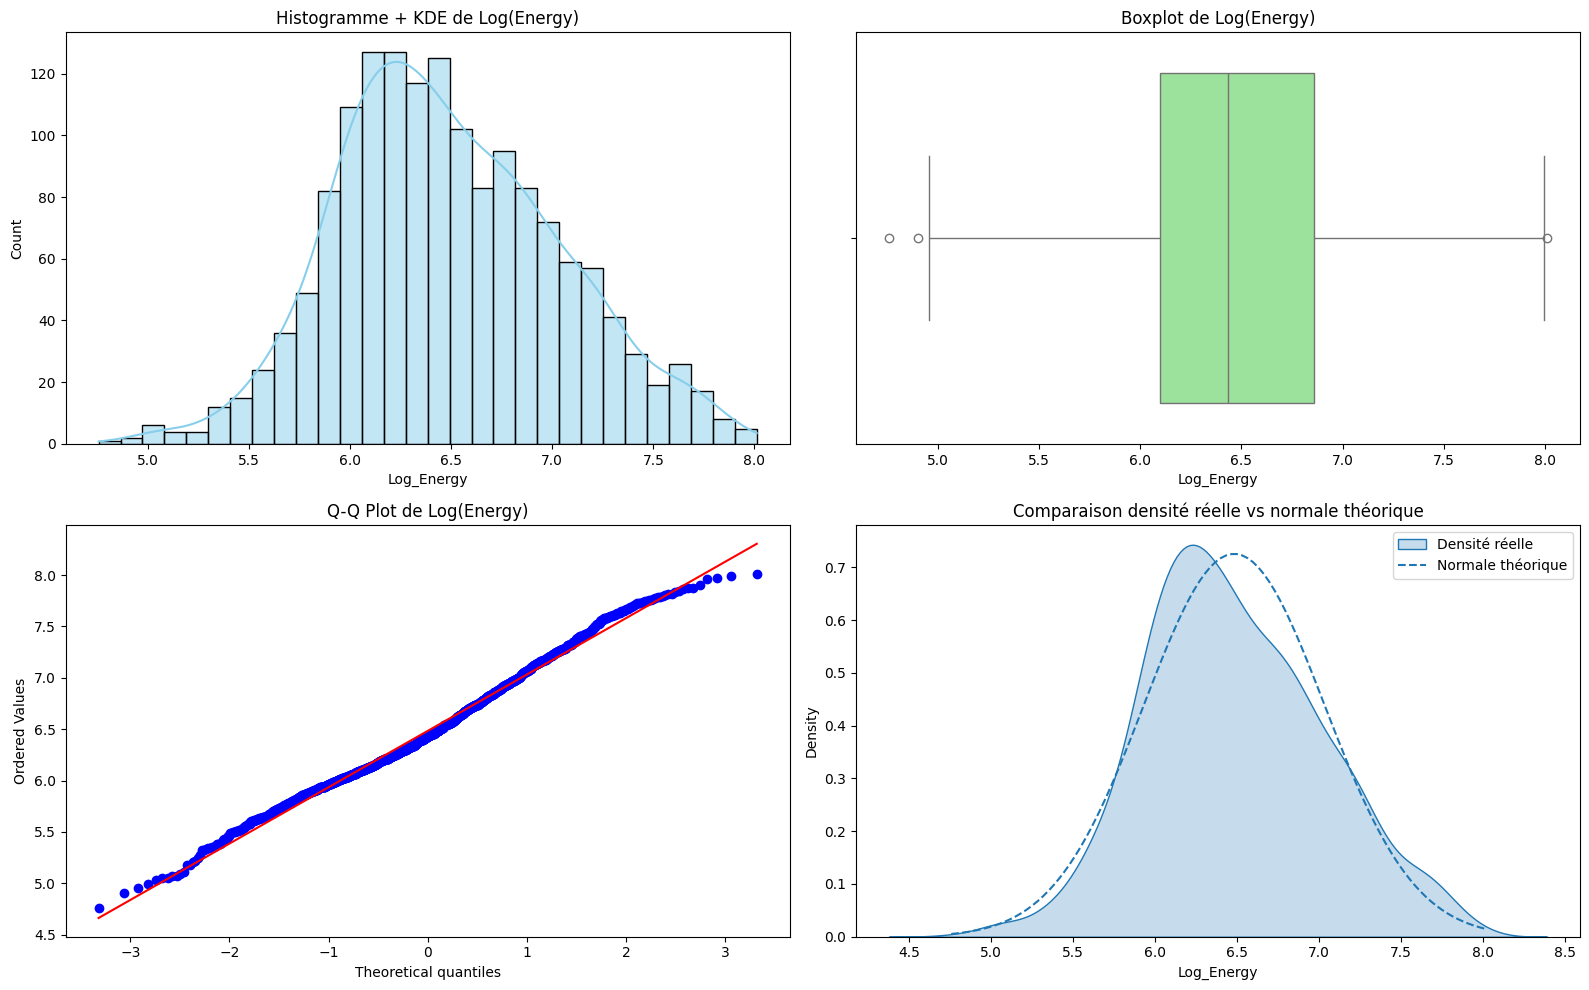

In [36]:

import scipy.stats as stats
import numpy as np

# Copie du DataFrame pour manipulation
df = building_consumption.copy()

# On garde la variable d'intérêt et on filtre les valeurs manquantes ou nulles
df = df[['SiteEnergyUse(kBtu)']].dropna()
df = df[df['SiteEnergyUse(kBtu)'] > 0]

# Transformation logarithmique pour atténuer les valeurs extrêmes
df['Log_Energy'] = np.log10(df['SiteEnergyUse(kBtu)'])

# Créer une figure avec plusieurs visualisations
plt.figure(figsize=(16, 10))

# 1. Histogramme + courbe KDE
plt.subplot(2, 2, 1)
sns.histplot(df['Log_Energy'], kde=True, bins=30, color='skyblue')
plt.title("Histogramme + KDE de Log(Energy)")

# 2. Boîte à moustaches (boxplot)
plt.subplot(2, 2, 2)
sns.boxplot(x=df['Log_Energy'], color='lightgreen')
plt.title("Boxplot de Log(Energy)")

# 3. Q-Q plot (quantile-quantile plot) pour tester la normalité
plt.subplot(2, 2, 3)
stats.probplot(df['Log_Energy'], dist="norm", plot=plt)
plt.title("Q-Q Plot de Log(Energy)")

# 4. Densité empirique comparée à la courbe normale
plt.subplot(2, 2, 4)
sns.kdeplot(df['Log_Energy'], label='Densité réelle', fill=True)
mean = df['Log_Energy'].mean()
std = df['Log_Energy'].std()
x = np.linspace(df['Log_Energy'].min(), df['Log_Energy'].max(), 100)
plt.plot(x, stats.norm.pdf(x, mean, std), label='Normale théorique', linestyle='--')
plt.title("Comparaison densité réelle vs normale théorique")
plt.legend()

plt.tight_layout()
plt.show()


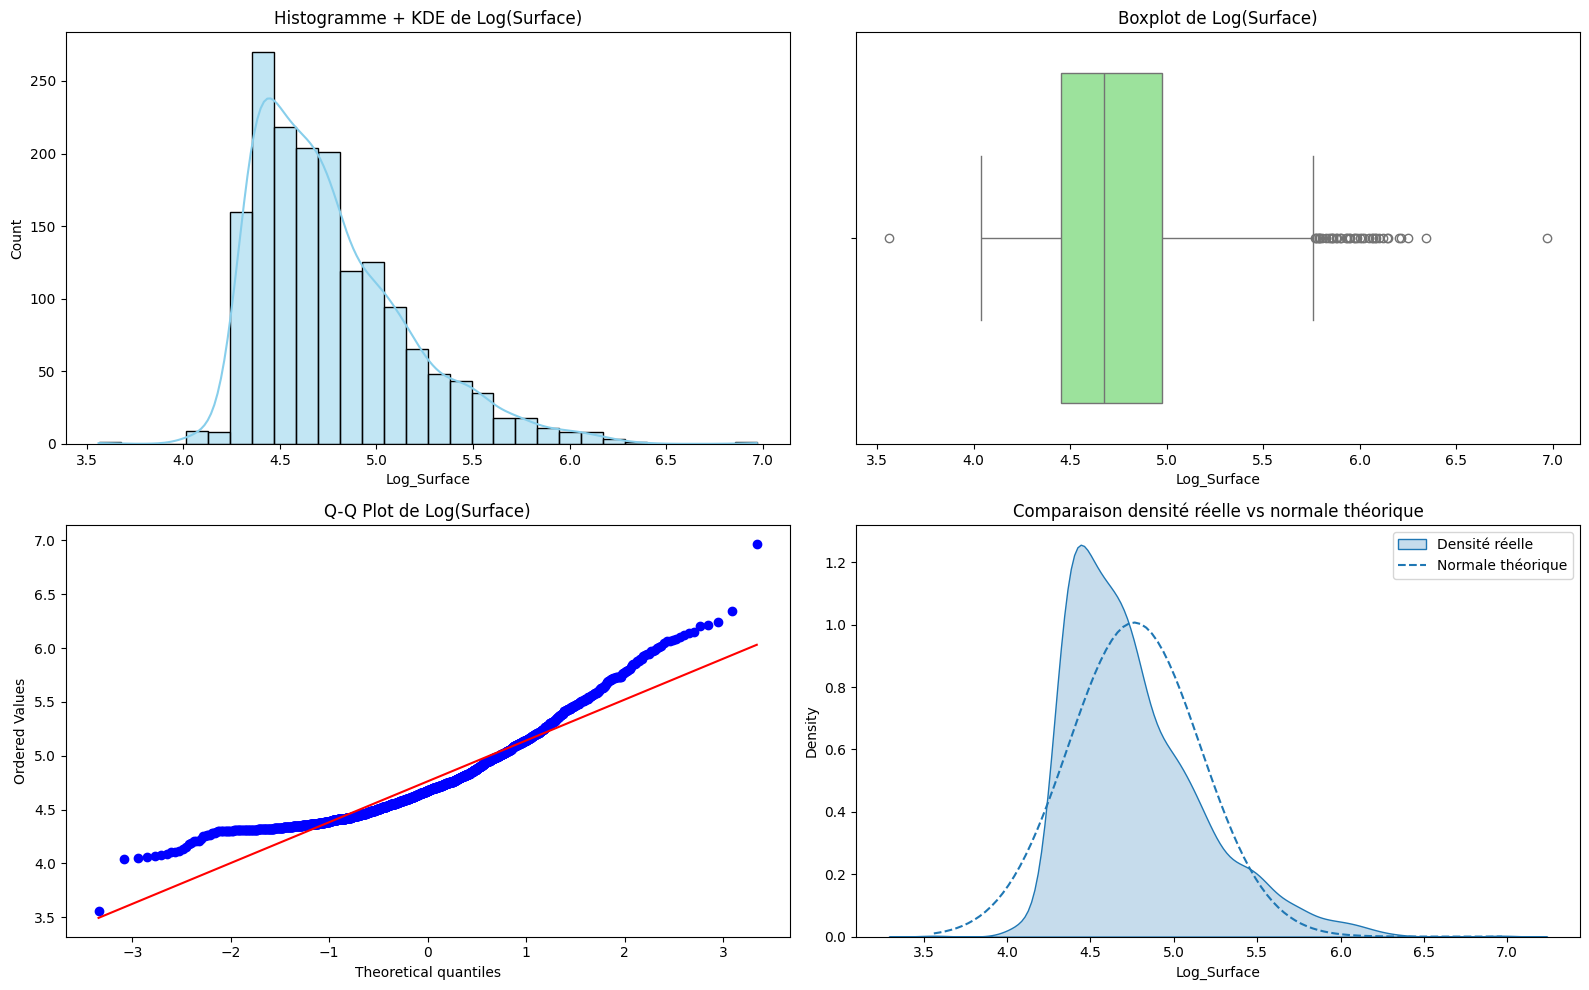

In [16]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Copie du DataFrame pour manipulation
df = building_consumption.copy()

# Filtrage : on garde la variable d'intérêt et on enlève les valeurs nulles ou nulles
df = df[['PropertyGFABuilding(s)']].dropna()
df = df[df['PropertyGFABuilding(s)'] > 0]

# Transformation logarithmique base 10
df['Log_Surface'] = np.log10(df['PropertyGFABuilding(s)'])

# Figure composée
plt.figure(figsize=(16, 10))

# 1. Histogramme + KDE
plt.subplot(2, 2, 1)
sns.histplot(df['Log_Surface'], kde=True, bins=30, color='skyblue')
plt.title("Histogramme + KDE de Log(Surface)")

# 2. Boxplot
plt.subplot(2, 2, 2)
sns.boxplot(x=df['Log_Surface'], color='lightgreen')
plt.title("Boxplot de Log(Surface)")

# 3. Q-Q Plot
plt.subplot(2, 2, 3)
stats.probplot(df['Log_Surface'], dist="norm", plot=plt)
plt.title("Q-Q Plot de Log(Surface)")

# 4. Comparaison densité réelle vs loi normale
plt.subplot(2, 2, 4)
sns.kdeplot(df['Log_Surface'], label='Densité réelle', fill=True)
mean = df['Log_Surface'].mean()
std = df['Log_Surface'].std()
x = np.linspace(df['Log_Surface'].min(), df['Log_Surface'].max(), 100)
plt.plot(x, stats.norm.pdf(x, mean, std), label='Normale théorique', linestyle='--')
plt.title("Comparaison densité réelle vs normale théorique")
plt.legend()

plt.tight_layout()
plt.show()



## 🧠 Détection des anomalies combinées : énergie et surface

### 🎯 Objectif du script

Ce script vise à identifier les **bâtiments présentant des valeurs anormalement élevées ou basses** en termes de :

* **Consommation énergétique** (`SiteEnergyUse(kBtu)`)
* **Surface de bâtiment** (`PropertyGFABuilding(s)`)

L’idée est de repérer **les bâtiments "hors normes"** sur ces deux dimensions **simultanément**, car ils peuvent indiquer :

* des erreurs de saisie,
* des cas particuliers à étudier,
* ou des projets énergivores massifs (centres commerciaux, hôpitaux, data centers...).

---

### 📊 Variables analysées

| Variable                 | Description                                               | Unité                              |
| ------------------------ | --------------------------------------------------------- | ---------------------------------- |
| `SiteEnergyUse(kBtu)`    | Consommation d’énergie totale sur site                    | kBtu (mille British Thermal Units) |
| `PropertyGFABuilding(s)` | Surface totale du ou des bâtiments construits sur le site | pieds carrés (sq ft)               |

> Pour faciliter l’interprétation, le script convertit :
>
> * la surface en **mètres carrés (m²)** ;
> * l’énergie en **kilowattheures (kWh)** (1 kBtu ≈ 0,293 kWh).

---

### 🔍 Méthodologie de détection

#### 🔹 Anomalies sur la **consommation d’énergie**

On utilise un **Z-score** (écart standardisé) :

* Un bâtiment est considéré comme "outlier" énergétique si sa consommation est à plus de **3 écarts-types** de la moyenne.
* Cela revient à isoler les **1 % des cas les plus extrêmes** dans une distribution normale.

#### 🔹 Anomalies sur la **surface**

On utilise la **méthode des quartiles (IQR)** :

* On calcule l’intervalle interquartile (Q3 - Q1),
* On considère comme "outlier surfacique" tout bâtiment :

  * plus petit que Q1 - 1.5 × IQR
  * ou plus grand que Q3 + 1.5 × IQR

> Cette méthode est robuste, car elle ne dépend pas d’une distribution normale.

#### ✅ Filtrage final

Le script conserve **uniquement les bâtiments qui sont considérés comme outliers à la fois** :

* sur la consommation,
* **et** sur la surface.

---

### 📁 Contenu du fichier exporté

Le fichier CSV `outliers_surface_energy.csv` contient, pour chaque bâtiment :

* `OSEBuildingID` : identifiant unique du bâtiment
* sa consommation énergétique (`kBtu` et convertie en `kWh`)
* sa surface (`sq ft` et convertie en `m²`)
* deux indicateurs booléens (`True`/`False`) :

  * `outlier_energy`
  * `outlier_surface`

---

### 🧩 Pourquoi croiser énergie et surface ?

Il est essentiel d’analyser la consommation énergétique **en lien avec la taille** du bâtiment.

#### Exemples pour bien comprendre :

| Type de bâtiment                              | Surface (m²)                                 | Conso. attendue (kWh/an)  | Interprétation                         |
| --------------------------------------------- | -------------------------------------------- | ------------------------- | -------------------------------------- |
| Petite boutique                               | 150 m²                                       | 15 000 – 25 000 kWh       | Normal                                 |
| Bureau classique                              | 1000 m²                                      | 100 000 – 200 000 kWh     | Normal                                 |
| Grand supermarché                             | 5000 m²                                      | 500 000 – 1 000 000 kWh   | Normal                                 |
| Salle serveur (data center)                   | 800 m²                                       | 2 000 000+ kWh            | ⚠️ Très élevé, mais peut être justifié |
| Gymnase de 800 m²                             | 150 000 kWh                                  | ⚠️ Moyen/haut selon usage |                                        |
| Bâtiment de 1000 m² consommant 10 000 000 kWh | ❌ Anomalie probable ou usage très spécifique |                           |                                        |

> L’objectif est donc d’isoler **les cas qui s’éloignent trop de cette logique**, par exemple :
>
> * un bâtiment de 500 m² consommant 5 millions de kWh,
> * ou un bâtiment de 100 000 m² consommant très peu.

---

### 📌 Ce que permet ce script

* Repérer les **erreurs de saisie ou doublons** (valeurs multipliées par 10 ou 100).
* Identifier des **cas extrêmes à analyser** : bâtiments énergivores ou inefficaces.
* Servir de base à une **analyse énergétique comparative** ou une **préparation au machine learning**.



In [37]:

# 📂 Chargement des données
df = pd.read_csv("data/2016_Building_Energy_Benchmarking_ML.csv")

# ⚙️ Paramètres d’outliers
z_thresh = 3
iqr_factor = 1.5

# 🧠 Calcul du Z-score sur l’énergie
df['z_score_energy'] = np.abs(stats.zscore(df['SiteEnergyUse(kBtu)'].dropna()))
df['outlier_energy'] = df['z_score_energy'] > z_thresh

# 🧠 Détection IQR sur la surface
Q1 = df['PropertyGFABuilding(s)'].quantile(0.25)
Q3 = df['PropertyGFABuilding(s)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - iqr_factor * IQR
upper_bound = Q3 + iqr_factor * IQR
df['outlier_surface'] = (df['PropertyGFABuilding(s)'] < lower_bound) | (df['PropertyGFABuilding(s)'] > upper_bound)

# 🎯 Filtrer les outliers communs (énergie ET surface)
outliers_filtered = df[(df['outlier_energy']) & (df['outlier_surface'])].copy()

# ➕ Conversion et colonnes utiles
outliers_filtered['Surface (m²)'] = outliers_filtered['PropertyGFABuilding(s)'] * 0.092903
outliers_filtered['Énergie (kWh)'] = outliers_filtered['SiteEnergyUse(kBtu)'] * 0.29307107

# 🎯 Colonnes à garder pour clarté
columns_to_display = [
    'OSEBuildingID',
    'SiteEnergyUse(kBtu)',
    'Énergie (kWh)',
    'PropertyGFABuilding(s)',
    'Surface (m²)',
    'outlier_energy',
    'outlier_surface'
]

# 📋 Tableau final propre
final_outliers = outliers_filtered[columns_to_display]

# 💾 Sauvegarde du CSV
output_path = "data/outliers_surface_energy.csv"
final_outliers.to_csv(output_path, index=False)

# 👁️ Affichage lisible
print("📊 Outliers détectés (énergie ET surface) :\n")
print(final_outliers.head(50).to_string(index=False))


📊 Outliers détectés (énergie ET surface) :

 OSEBuildingID  SiteEnergyUse(kBtu)  Énergie (kWh)  PropertyGFABuilding(s)  Surface (m²)  outlier_energy  outlier_surface
            43          448385312.0   1.314088e+08                  494835  45971.656005            True             True
           198          253832464.0   7.439095e+07                  879000  81661.737000            True             True
           268          143423024.0   4.203314e+07                  597519  55511.307657            True             True
           276          293090784.0   8.589643e+07                 1158691 107645.869973            True             True
           477          131373880.0   3.850188e+07                  535947  49791.084141            True             True
           753          274682208.0   8.050141e+07                  429405  39893.012715            True             True
           828          291614432.0   8.546375e+07                 1765970 164063.910910            Tr

# 🧼 Nettoyage Avancé : Outliers Extrêmes & Corrélations entre Variables

Ce notebook réalise un nettoyage complet et contrôlé du dataset
**Building Energy Benchmarking**, incluant :

---

## 1. Suppression des outliers extrêmes

À partir du fichier `top_extreme_intensity_outliers.csv`, les bâtiments présentant une
**intensité énergétique anormalement élevée** (outliers extrêmes) sont retirés
du dataset principal.

Cela permet d’éviter que quelques valeurs exceptionnellement aberrantes
perturbent les analyses et les modèles prédictifs.

---

## 2. Encodage des variables catégorielles

Afin de calculer une matrice de corrélation fiable, toutes les colonnes
catégorielles sont encodées avec `LabelEncoder`.  
Chaque catégorie devient un entier unique.

---

## 3. Matrice de corrélation sur *toutes* les variables numériques

Aucune colonne n’est sélectionnée manuellement.  
Toutes les variables numériques issues du dataset (y compris les encodages)
sont intégrées.

Une **heatmap** permet de visualiser la structure globale des dépendances.

---

## 4. Détection des paires corrélées ≥ 0.85

Après calcul, toutes les paires de variables possédant une corrélation
absolue **supérieure ou égale à 0.85** sont listées.

Une corrélation très élevée peut indiquer :

- Redondance totale (ex : surface totale vs surface bâtiment)
- Variables dérivées l’une de l’autre
- Mesures du même phénomène avec échelle différente

---

## 5. Suppression interactive des variables redondantes

Pour chaque paire fortement corrélée, le script propose :

- Supprimer la **première** variable
- Supprimer la **deuxième** variable
- Ne supprimer **aucune** des deux

L’utilisateur conserve ainsi un contrôle total sur la décision.

---

## 6. Sauvegarde du dataset nettoyé

Après toutes les suppressions choisies, les données finales sont écrites dans : cleaned_2016_Building_Energy_Benchmarking_ML.csv



ℹ️ Sauvegarde déjà existante : data/backup_2016_Building_Energy_Benchmarking_ML.csv
✔️ Outliers supprimés : 10 lignes


C:\Users\karap\AppData\Local\Temp\ipykernel_7776\3860759524.py:32: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')  # conserve strings si pas convertible


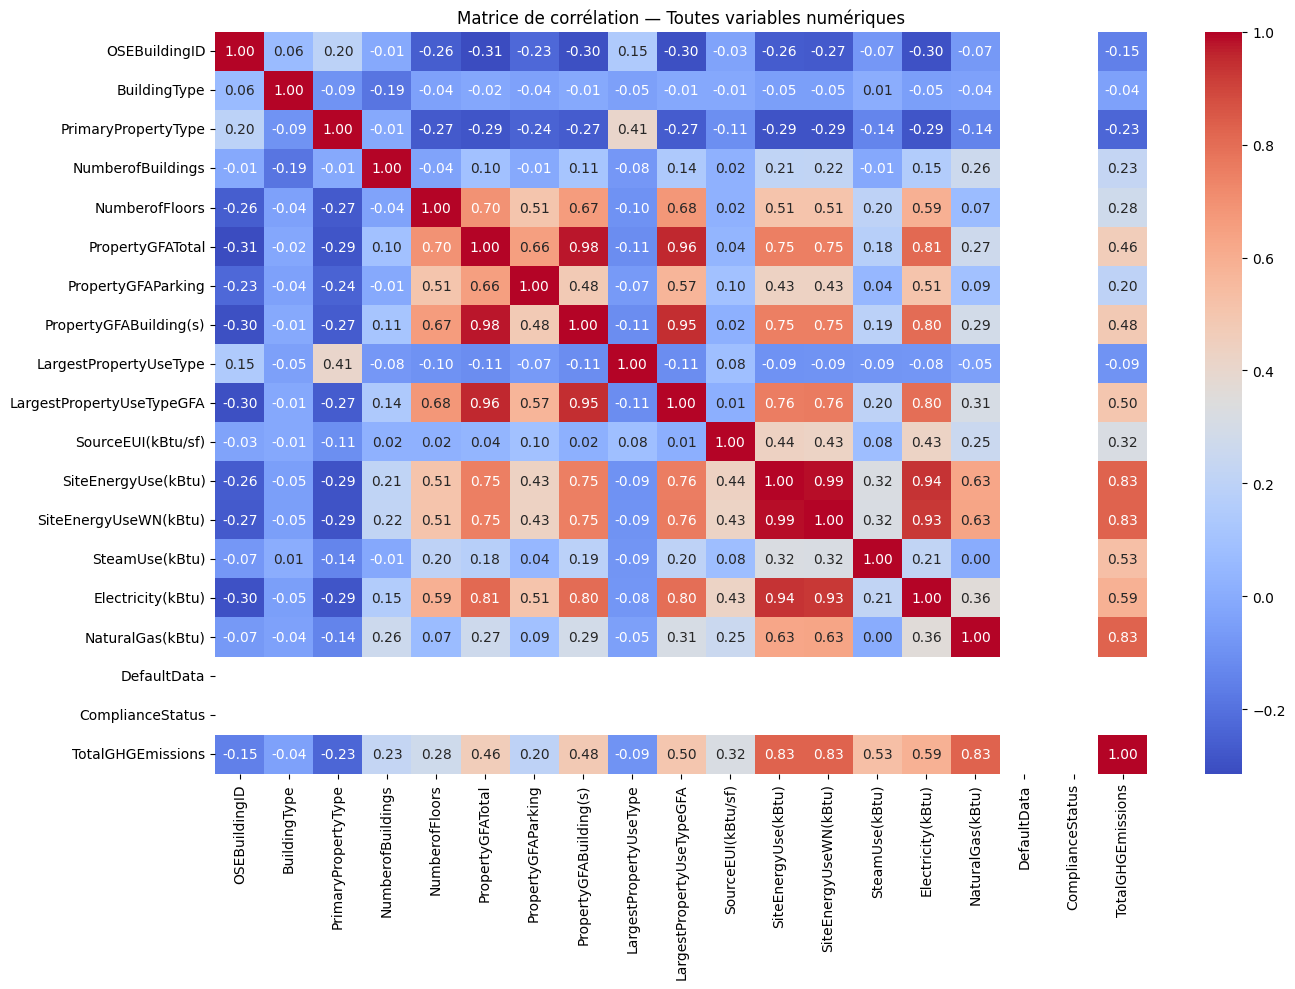


🔍 Paires fortement corrélées (≥ 0.85) :
                       Var1                       Var2  Correlation
71         PropertyGFATotal     PropertyGFABuilding(s)     0.977456
73         PropertyGFATotal  LargestPropertyUseTypeGFA     0.955021
92   PropertyGFABuilding(s)  LargestPropertyUseTypeGFA     0.948627
121     SiteEnergyUse(kBtu)      SiteEnergyUseWN(kBtu)     0.988868
123     SiteEnergyUse(kBtu)          Electricity(kBtu)     0.935865
127   SiteEnergyUseWN(kBtu)          Electricity(kBtu)     0.925473

⚠️ Corrélation forte : PropertyGFATotal ↔ PropertyGFABuilding(s) (corr = 0.98)
   1 → supprimer Var1
   2 → supprimer Var2
   0 → ne rien supprimer


Votre choix (0/1/2) :  1


🗑️ Colonne supprimée : PropertyGFATotal

⚠️ Corrélation forte : PropertyGFATotal ↔ LargestPropertyUseTypeGFA (corr = 0.96)
   1 → supprimer Var1
   2 → supprimer Var2
   0 → ne rien supprimer


Votre choix (0/1/2) :  1


🗑️ Colonne supprimée : PropertyGFATotal

⚠️ Corrélation forte : PropertyGFABuilding(s) ↔ LargestPropertyUseTypeGFA (corr = 0.95)
   1 → supprimer Var1
   2 → supprimer Var2
   0 → ne rien supprimer


...

🗑️ Colonne supprimée : SiteEnergyUseWN(kBtu)

⚠️ Corrélation forte : SiteEnergyUse(kBtu) ↔ Electricity(kBtu) (corr = 0.94)
   1 → supprimer Var1
   2 → supprimer Var2
   0 → ne rien supprimer


Votre choix (0/1/2) :  0


✔️ Aucune suppression pour cette paire.

⚠️ Corrélation forte : SiteEnergyUseWN(kBtu) ↔ Electricity(kBtu) (corr = 0.93)
   1 → supprimer Var1
   2 → supprimer Var2
   0 → ne rien supprimer


Votre choix (0/1/2) :  1


🗑️ Colonne supprimée : SiteEnergyUseWN(kBtu)

📌 Colonnes supprimées : ['PropertyGFATotal', 'SiteEnergyUseWN(kBtu)']

✅ Données nettoyées enregistrées dans : data/cleaned_2016_Building_Energy_Benchmarking_ML.csv


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import os

# 🔹 Étape 1 : Chargement des fichiers
main_file = "data/2016_Building_Energy_Benchmarking_ML.csv"
outliers_file = "data/outliers_surface_energy.csv"
backup_file = "data/backup_2016_Building_Energy_Benchmarking_ML.csv"
clean_file = "data/cleaned_2016_Building_Energy_Benchmarking_ML.csv"

df = pd.read_csv(main_file)
df_outliers = pd.read_csv(outliers_file)

# 🔹 Étape 2 : Sauvegarde de sécurité
if not os.path.exists(backup_file):
    df.to_csv(backup_file, index=False)
    print("✔️ Sauvegarde créée :", backup_file)
else:
    print("ℹ️ Sauvegarde déjà existante :", backup_file)

# 🔹 Étape 3 : Suppression des outliers extrêmes
# risque de data leekage outlier_ids = df_outliers.query("outlier_surface == True and outlier_energy == True")['OSEBuildingID']
outlier_ids = df_outliers.query("outlier_surface == True")['OSEBuildingID']
df = df[~df['OSEBuildingID'].isin(outlier_ids)]
print(f"✔️ Outliers supprimés : {outlier_ids.shape[0]} lignes")

# 🔹 Étape 4 : Correction automatique des types numériques
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')  # conserve strings si pas convertible

# 🔹 Étape 5 : Encodage de toutes les colonnes non numériques
df_corr = df.copy()
categorical_cols = df_corr.select_dtypes(include=['object', 'category']).columns

encoder = LabelEncoder()
for col in categorical_cols:
    df_corr[col] = encoder.fit_transform(df_corr[col].astype(str))

# 🔹 Étape 6 : Matrice de corrélation complète
corr_matrix = df_corr.corr(numeric_only=True)

# 🔹 Affichage de la heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Matrice de corrélation — Toutes variables numériques")
plt.tight_layout()
plt.show()

# 🔹 Étape 7 : Détection des corrélations ≥ 0.85
pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
pairs.columns = ['Var1', 'Var2', 'Correlation']
pairs = pairs[pairs['Correlation'] >= 0.85]

print("\n🔍 Paires fortement corrélées (≥ 0.85) :")
print(pairs)

# 🔹 Étape 8 : Suppression interactive
cols_to_drop = []
for _, row in pairs.iterrows():
    v1, v2, corr = row['Var1'], row['Var2'], row['Correlation']
    print(f"\n⚠️ Corrélation forte : {v1} ↔ {v2} (corr = {corr:.2f})")
    print("   1 → supprimer Var1")
    print("   2 → supprimer Var2")
    print("   0 → ne rien supprimer")
    choice = input("Votre choix (0/1/2) : ")

    if choice == "1":
        cols_to_drop.append(v1)
        print(f"🗑️ Colonne supprimée : {v1}")
    elif choice == "2":
        cols_to_drop.append(v2)
        print(f"🗑️ Colonne supprimée : {v2}")
    else:
        print("✔️ Aucune suppression pour cette paire.")

# 🔹 Étape 9 : Suppression des colonnes sélectionnées
cols_to_drop = list(set(cols_to_drop))
print("\n📌 Colonnes supprimées :", cols_to_drop)
df_cleaned = df.drop(columns=cols_to_drop)

# 🔹 Étape 10 : Sauvegarde finale
df_cleaned.to_csv(clean_file, index=False)
print(f"\n✅ Données nettoyées enregistrées dans : {clean_file}")


In [5]:
# 1. Chargement des données et aperçu général 
building_consumption = pd.read_csv("data/cleaned_2016_Building_Energy_Benchmarking_ML.csv")
# Aperçu général
print("Dimensions :", building_consumption.shape)
print("\nColonnes :", building_consumption.columns.tolist())
building_consumption.head()

# 2. Informations générales sur les colonnes
# Infos sur les types de données et valeurs non nulles
building_consumption.info()



Dimensions : (1536, 17)

Colonnes : ['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SourceEUI(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'DefaultData', 'ComplianceStatus', 'TotalGHGEmissions']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   OSEBuildingID              1536 non-null   int64  
 1   BuildingType               1536 non-null   object 
 2   PrimaryPropertyType        1536 non-null   object 
 3   NumberofBuildings          1536 non-null   float64
 4   NumberofFloors             1536 non-null   int64  
 5   PropertyGFAParking         1536 non-null   int64  
 6   PropertyGFABuilding(s)     1536 non-null   in